<a href="https://colab.research.google.com/github/MAD-MAX95/-Diabetes-Prediction-App/blob/main/Logitstic_Reg.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

1. Importing the libraries

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score,recall_score,f1_score,roc_auc_score,roc_curve,precision_score
import warnings
warnings.filterwarnings('ignore')



2. Data Exploration:

In [5]:
df=pd.read_csv('diabetes.csv')
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [7]:
df.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [8]:
# Checking for any null Values present in the data
df.isnull().sum()

,0
Pregnancies,0
Glucose,0
BloodPressure,0
SkinThickness,0
Insulin,0
BMI,0
DiabetesPedigreeFunction,0
Age,0
Outcome,0


### Data Visualization

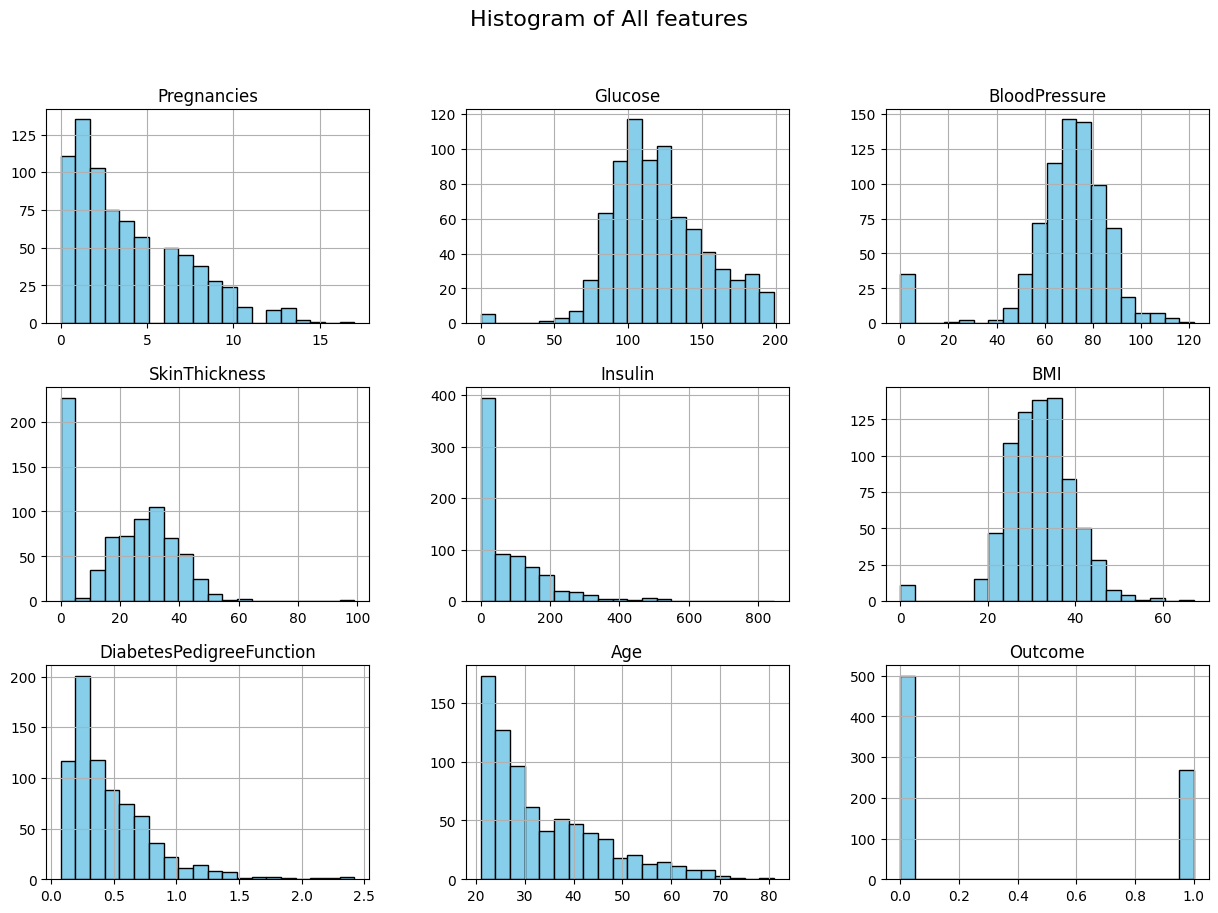

In [9]:
df.hist(bins=20,figsize=(15,10),color='skyblue',edgecolor='black')
plt.suptitle('Histogram of All features',fontsize=16)
plt.show()

### Comparing every features against the Target Variable Outcome

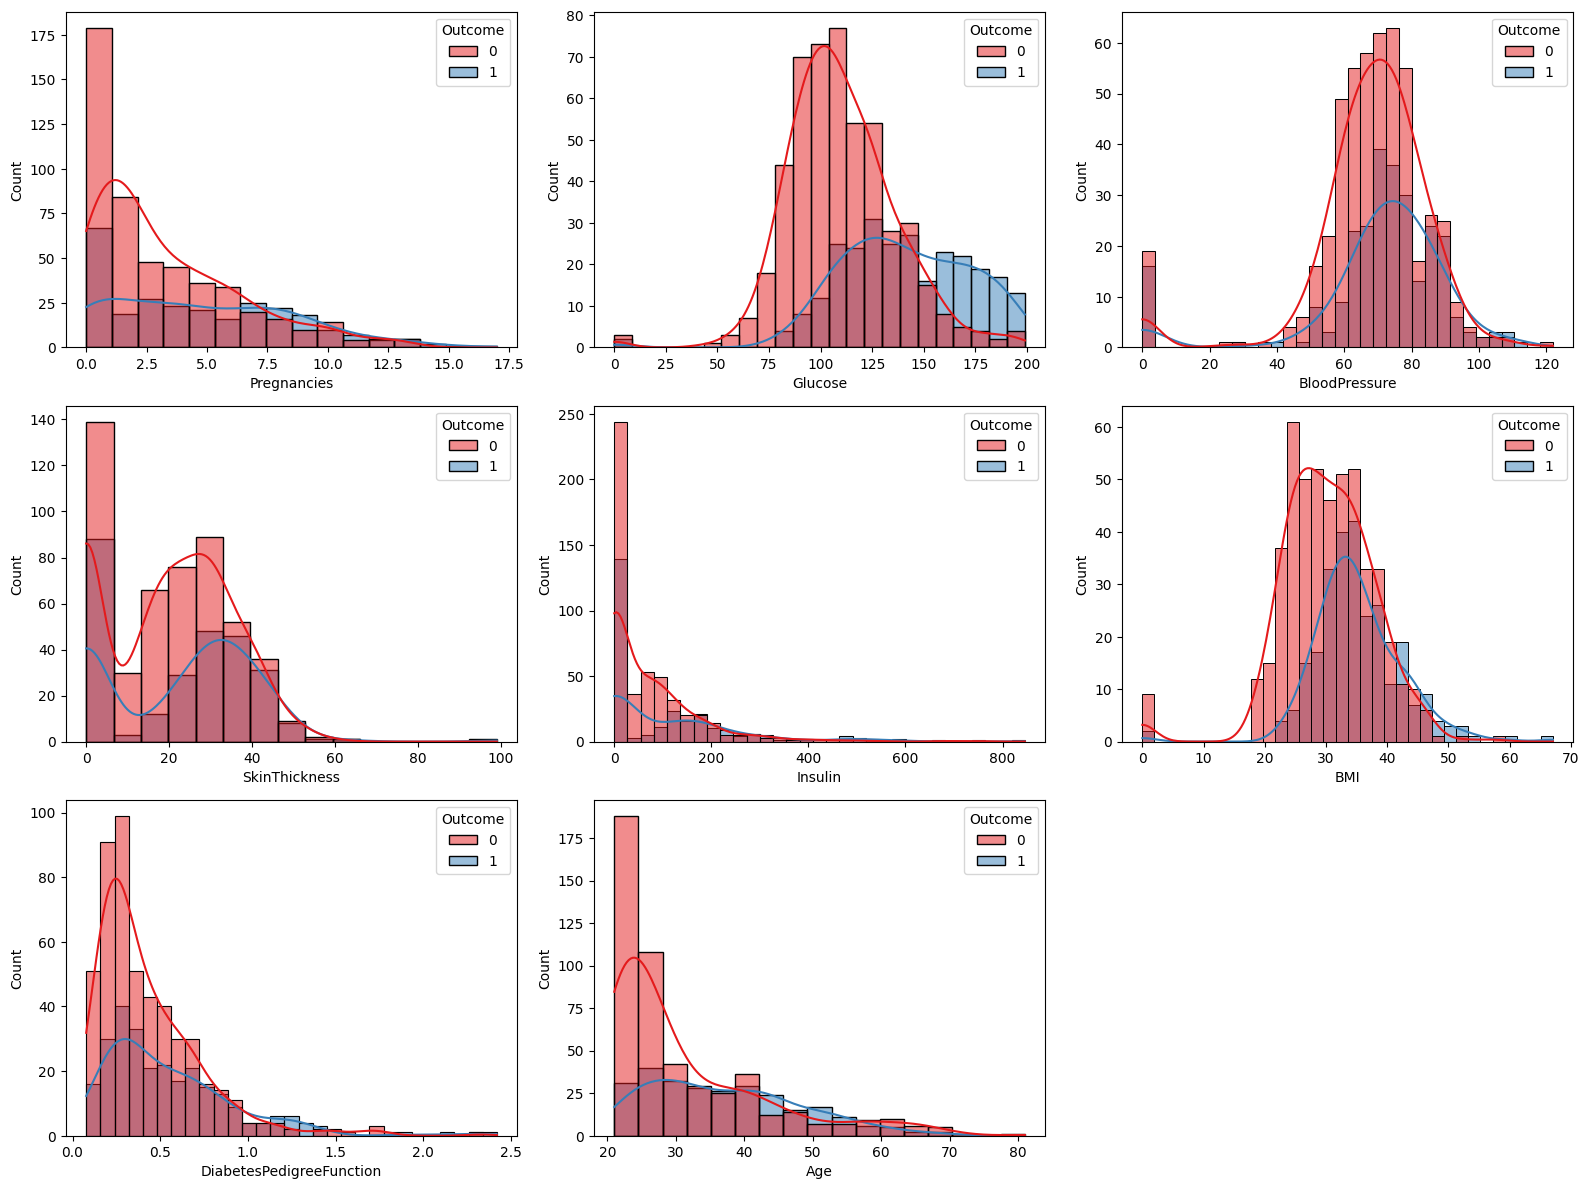

In [10]:
features=df.columns.drop('Outcome') # selecting all feature except outcome
plt.figure(figsize=(16,12))

for i,col in enumerate(features,1):
  plt.subplot(3,3,i)

  sns.histplot(data=df,x=col,hue='Outcome',kde=True,palette='Set1')

plt.tight_layout()
plt.show()


### Box Plots for All Features

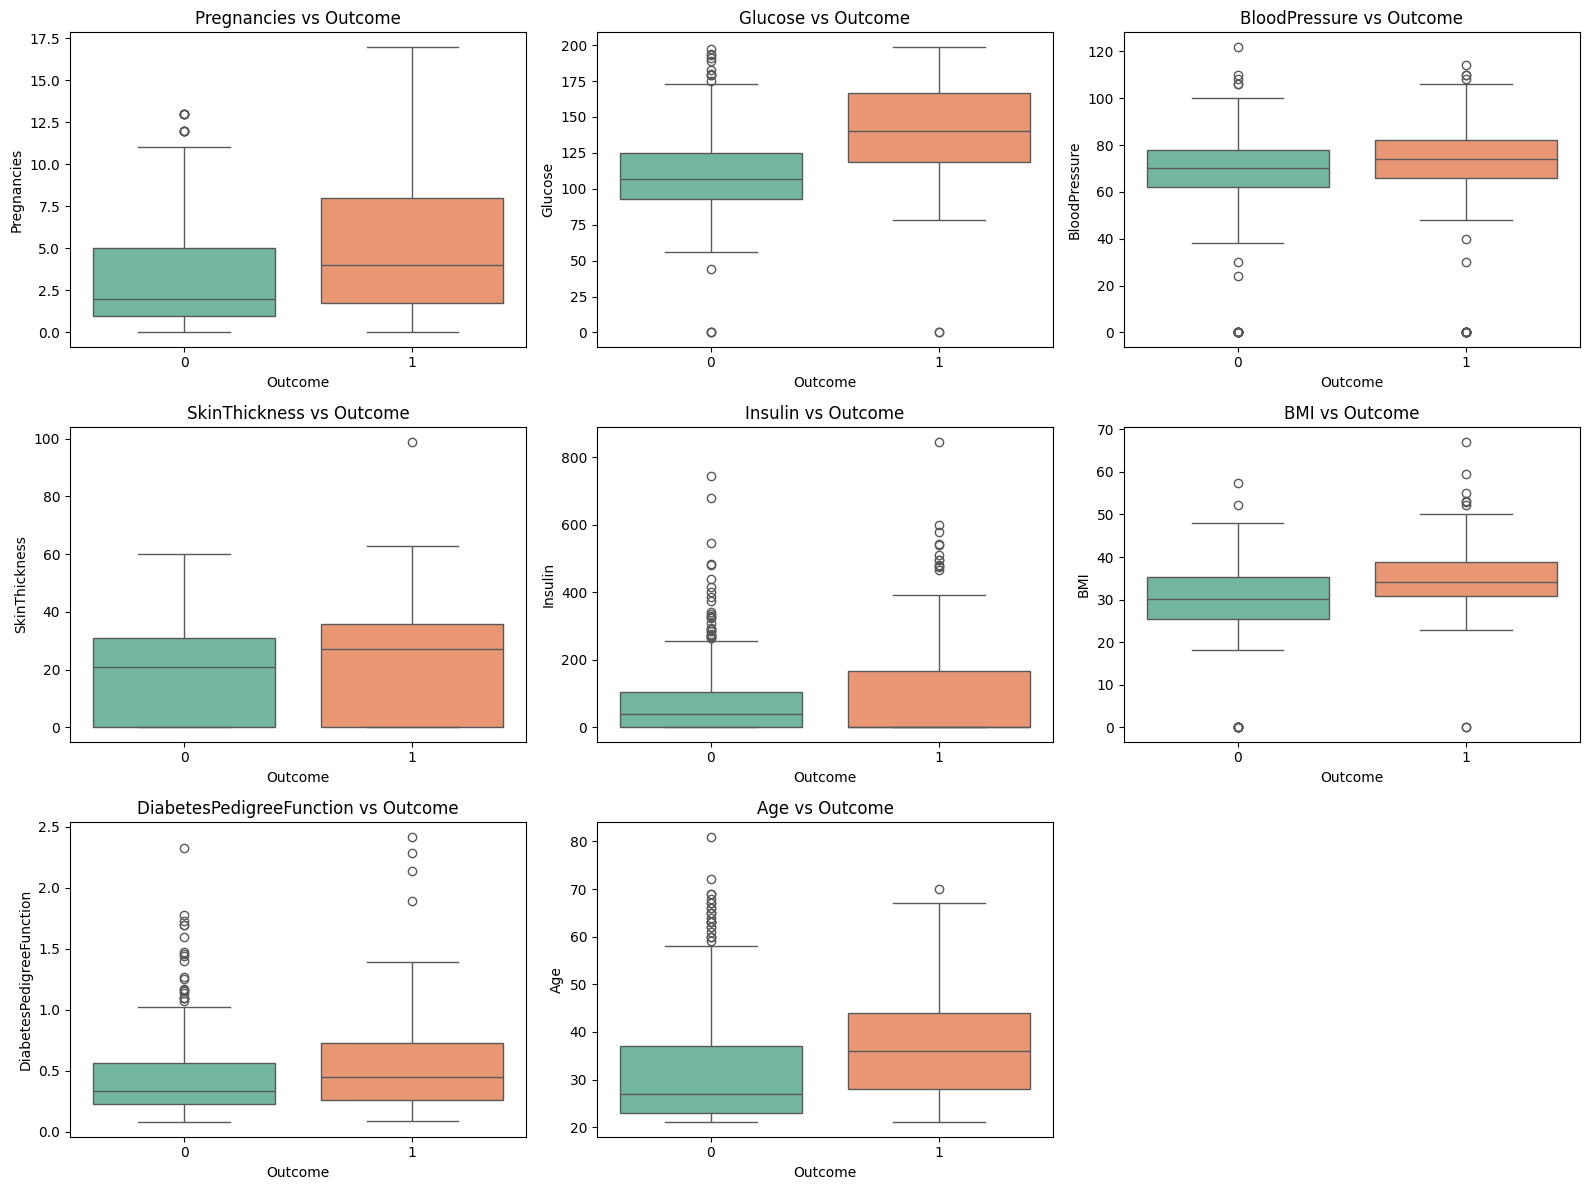

In [11]:
# Get all columns except the target
features = df.columns.drop('Outcome')

# Set up the figure
plt.figure(figsize=(16, 12))

# Loop through and create a boxplot for each feature
for i, col in enumerate(features, 1):
    plt.subplot(3, 3, i)
    sns.boxplot(data=df, x='Outcome', y=col, palette='Set2')
    plt.title(f'{col} vs Outcome')

plt.tight_layout()
plt.show()

### Compare All Features at Once (Pairplot)

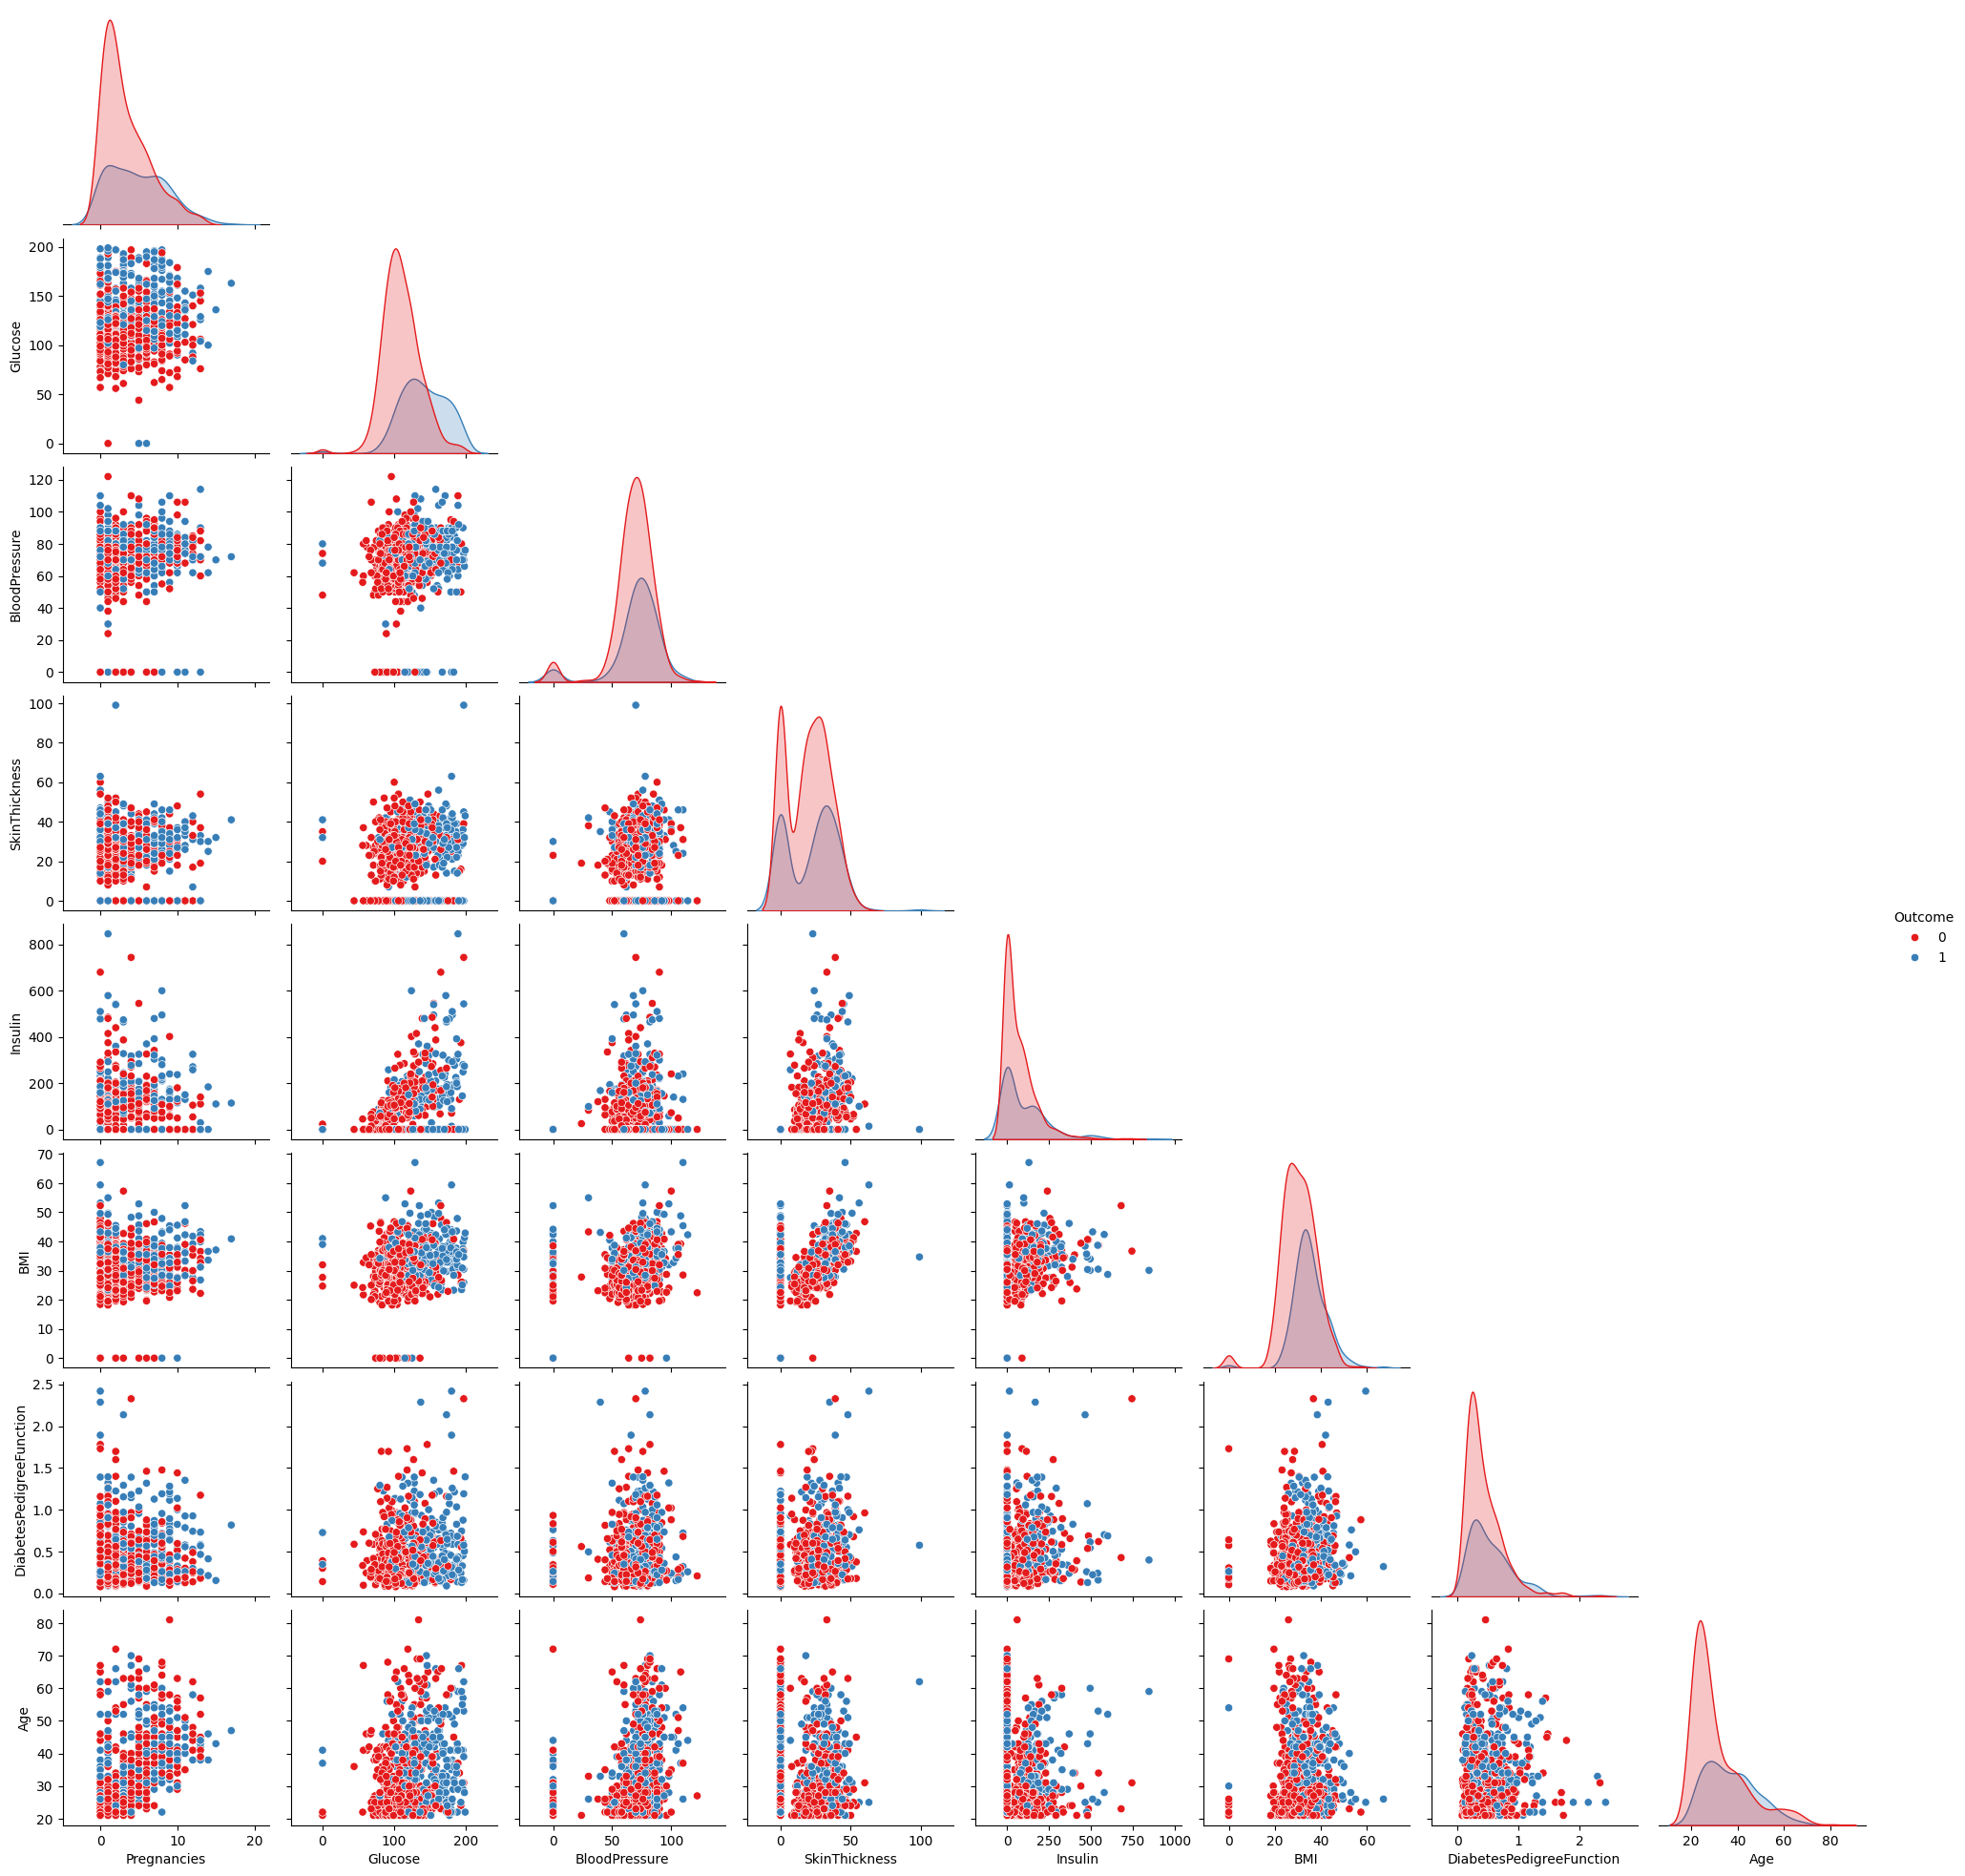

In [12]:

sns.pairplot(df, hue='Outcome', palette='Set1', corner=True)
plt.show()

TASK -2. Data Preprocessing:


a. Handle missing values (e.g., imputation).


b. Encode categorical variables.

These steps are skipped as the dataset has no missing values and categorical value.

TASK 3. Model Building:

In [13]:
### Splitting the data

X=df.drop('Outcome',axis=1)
y=df['Outcome']

X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)



In [14]:
### Fit the data into the model

model=LogisticRegression()
model.fit(X_train,y_train)


LogisticRegression()

In [15]:
y_pred=model.predict(X_test)


TASK 4. Model Evaluation:

In [16]:
## Calculating the standard metrics using y_pred
accuracy=accuracy_score(y_test,y_pred)
precision=precision_score(y_test,y_pred)
recall=recall_score(y_test,y_pred)
f1=f1_score(y_test,y_pred)

## Get the probability prediction for postive 'Outcome'
y_prob=model.predict_proba(X_test)[:,1]
roc_auc=roc_auc_score(y_test,y_prob)

## Print all the metrics
print("--- Model Evaluation Metrics ---")
print(f"Accuracy:  {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1-Score:  {f1:.4f}")
print(f"ROC-AUC:   {roc_auc:.4f}\n")


--- Model Evaluation Metrics ---
Accuracy:  0.7403
Precision: 0.6316
Recall:    0.6545
F1-Score:  0.6429
ROC-AUC:   0.8099



-> [predict_proba:] The ROC curve needs to know how confident the model was in its predictions, not just the final decision. predict_proba(X_test)[:, 1] grabs the percentage likelihood that the model thinks each patient has diabetes.

-> ROC Curve: Plots the trade-off between the True Positive Rate and False Positive Rate at different classification thresholds. The AUC (Area Under the Curve) tells you how well the model distinguishes between classes; a score of 1.0 is perfect, and 0.5 is no better than random guessing.

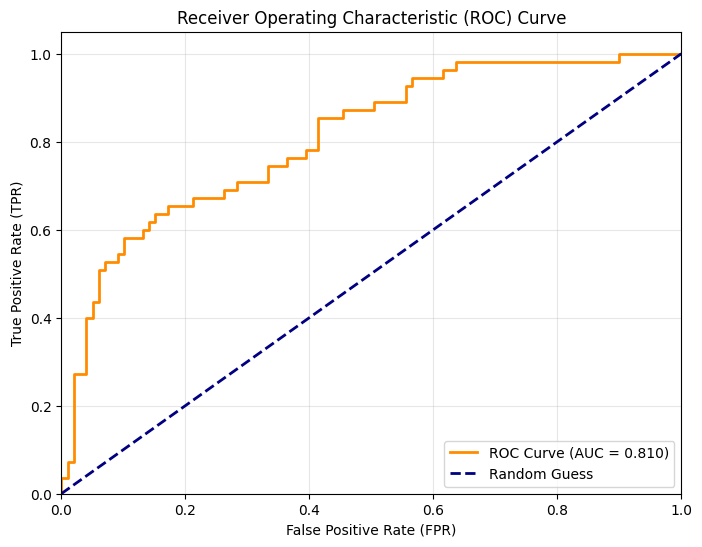

In [17]:
## Calculate False Positive Rate (FPR) and True Positive Rate (TPR) for the ROC curve
fpr, tpr, thresholds = roc_curve(y_test, y_prob)

##. Plot the ROC Curve
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC Curve (AUC = {roc_auc:.3f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random Guess')

## Formatting the plot
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (FPR)')
plt.ylabel('True Positive Rate (TPR)')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.show()

TASK 5. Interpretation:

a. Interpret the coefficients of the logistic regression model.

b. Discuss the significance of features in predicting the target variable (survival probability in this case).


--- Logistic Regression Coefficients ---
                    Feature  Coefficient
6  DiabetesPedigreeFunction     0.590023
5                       BMI     0.101520
0               Pregnancies     0.061063
7                       Age     0.037688
1                   Glucose     0.033789
2             BloodPressure    -0.013878
3             SkinThickness     0.004746
4                   Insulin    -0.001945


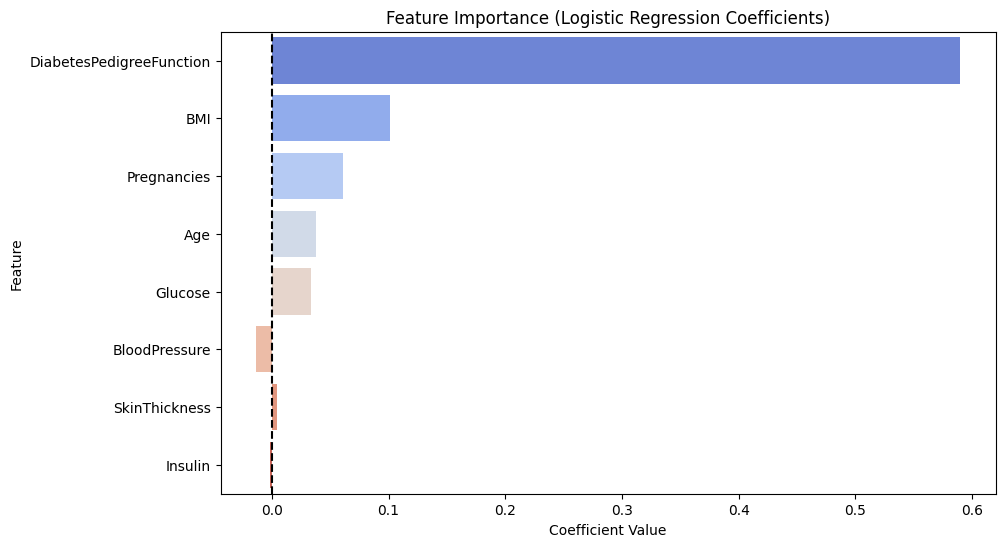

In [18]:
# Create a DataFrame to view the features and their corresponding coefficients
feature_names = X.columns
coefficients = model.coef_[0]

coeff_df = pd.DataFrame({
    'Feature': feature_names,
    'Coefficient': coefficients
})

# Add a column for the absolute value to help sort by impact magnitude
coeff_df['Abs_Coefficient'] = np.abs(coeff_df['Coefficient'])
coeff_df = coeff_df.sort_values(by='Abs_Coefficient', ascending=False)

print("--- Logistic Regression Coefficients ---")
print(coeff_df[['Feature', 'Coefficient']])

# Visualize the coefficients
plt.figure(figsize=(10, 6))
sns.barplot(x='Coefficient', y='Feature', data=coeff_df, palette='coolwarm')
plt.title('Feature Importance (Logistic Regression Coefficients)')
plt.axvline(x=0, color='black', linestyle='--')
plt.xlabel('Coefficient Value')
plt.ylabel('Feature')
plt.show()

a. Interpreting the Coefficients
In logistic regression, the coefficients represent the change in the log-odds of the target variable (Diabetes Outcome = 1) for a one-unit increase in the feature.

Positive Coefficients (Bars to the right of zero): As this feature increases, the probability of the patient having diabetes increases. For example, Glucose will likely have a positive coefficient, meaning higher glucose levels strongly correlate with a higher likelihood of diabetes.

Negative Coefficients (Bars to the left of zero): As this feature increases, the probability of the patient having diabetes decreases.

Near-Zero Coefficients: These features have very little linear impact on the model's decision.


b. Discussing the Significance of Features
To discuss significance, look at the absolute magnitude of the coefficients (how long the bars are in the plot, regardless of direction). The longer the bar, the more "weight" or importance the model gave to that feature when making a prediction.

Precision vs. Recall

-> Precision: Focuses on the quality of positive predictions. High precision means fewer false alarms (false positives).

->Recall: Focuses on the quantity of actual positives captured. High recall means fewer missed targets (false negatives).

->Trade-off: Raising the decision threshold increases precision and reduces recall, while lowering it does the reverse.What Is

 Cross-Validation?
  
->  Process: The dataset is divided into \(k\) equal subsets or "folds".Iteration: The model is trained on \(k-1\) folds and tested on the remaining single fold. This repeats \(k\) times so every fold acts as the test set once.

Aggregation: Performance scores from each round are averaged to yield a robust evaluation metric.

In [19]:
import pickle

# Save the model to a file named 'diabetes_model.pkl'
with open('diabetes_model.pkl', 'wb') as file:
    pickle.dump(model, file)

print("Model saved successfully!")

Model saved successfully!
